# Proyecto Machine Learning: Calidad de Vino con XGBoost

## Descripción del Proyecto
Este proyecto tiene como objetivo predecir si un vino es de buena o mala calidad utilizando el algoritmo **XGBoost**. 

El modelo entrenado analiza las características físico-químicas del producto para clasificarlo automáticamente, optimizando los procesos de control de calidad en la producción vitivinícola.

---

### Características Químicas del Vino (Features)
El modelo utilizará variables analíticas clave, tales como:
* Acidez fija
* Acidez volátil
* Ácido cítrico
* Azúcar residual
* Cloruros
* Dióxido de azufre (libre y total)
* Densidad
* pH
* Sulfatos
* Alcohol

### Variable Objetivo (Target)
La calidad del vino se evaluará mediante una clasificación binaria:
* **1** = Vino Bueno
* **0** = Vino Malo

### Tecnologías y Librerías Utilizadas
* **Python**: Lenguaje principal de desarrollo.
* **Pandas & NumPy**: Manipulación, limpieza y análisis exploratorio de datos.
* **Scikit-Learn**: Preprocesamiento de datos, escalado y métricas de evaluación del modelo.
* **XGBoost**: Algoritmo de Gradient Boosting para el entrenamiento del clasificador de alta precisión.
* **Joblib**: Serialización y guardado del modelo entrenado para su posterior producción.
* **Streamlit**: Creación de una interfaz web interactiva para desplegar el modelo en tiempo real.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

import joblib

In [6]:
# Cargar dataset

df = pd.read_csv('/workspaces/calidad-vino-xgboost/data/raw/calidad_de_vino.csv')

# Mostrar primeras filas
print(df.head())


   botella_id  acidez fija  acidez volatil  acido citrico  azucar residual  \
0           0          9.5            0.56           0.33              2.4   
1           1          6.6            0.24           0.28              1.8   
2           2          9.4            0.59           0.14              2.0   
3           3          6.1            0.32           0.33             10.7   
4           4          7.0            0.36           0.35              2.5   

   cloruros  dioxido de azufre libre  dioxido de azufre total  densidad    pH  \
0     0.089                     35.0                     67.0   0.99720  3.28   
1     0.028                     39.0                    132.0   0.99182  3.34   
2     0.084                     25.0                     48.0   0.99810  3.14   
3     0.036                     27.0                     98.0   0.99521  3.34   
4     0.048                     67.0                    161.0   0.99146  3.05   

   sulfatos  alcohol   color  calidad  
0   

In [7]:
# Información General del Dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   botella_id               6497 non-null   int64  
 1   acidez fija              6497 non-null   float64
 2   acidez volatil           6497 non-null   float64
 3   acido citrico            6497 non-null   float64
 4   azucar residual          6497 non-null   float64
 5   cloruros                 6497 non-null   float64
 6   dioxido de azufre libre  6497 non-null   float64
 7   dioxido de azufre total  6497 non-null   float64
 8   densidad                 6497 non-null   float64
 9   pH                       6497 non-null   float64
 10  sulfatos                 6497 non-null   float64
 11  alcohol                  6497 non-null   float64
 12  color                    6497 non-null   str    
 13  calidad                  6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
me

In [8]:
# Estadísticas Descriptivas
print(df.describe())

        botella_id  acidez fija  acidez volatil  acido citrico  \
count  6497.000000  6497.000000     6497.000000    6497.000000   
mean   3248.000000     7.215307        0.339666       0.318633   
std    1875.666681     1.296434        0.164636       0.145318   
min       0.000000     3.800000        0.080000       0.000000   
25%    1624.000000     6.400000        0.230000       0.250000   
50%    3248.000000     7.000000        0.290000       0.310000   
75%    4872.000000     7.700000        0.400000       0.390000   
max    6496.000000    15.900000        1.580000       1.660000   

       azucar residual     cloruros  dioxido de azufre libre  \
count      6497.000000  6497.000000              6497.000000   
mean          5.443235     0.056034                30.525319   
std           4.757804     0.035034                17.749400   
min           0.600000     0.009000                 1.000000   
25%           1.800000     0.038000                17.000000   
50%           3.00000

In [9]:
# Verificar Valores Nulos
print(df.isnull().sum())

botella_id                 0
acidez fija                0
acidez volatil             0
acido citrico              0
azucar residual            0
cloruros                   0
dioxido de azufre libre    0
dioxido de azufre total    0
densidad                   0
pH                         0
sulfatos                   0
alcohol                    0
color                      0
calidad                    0
dtype: int64


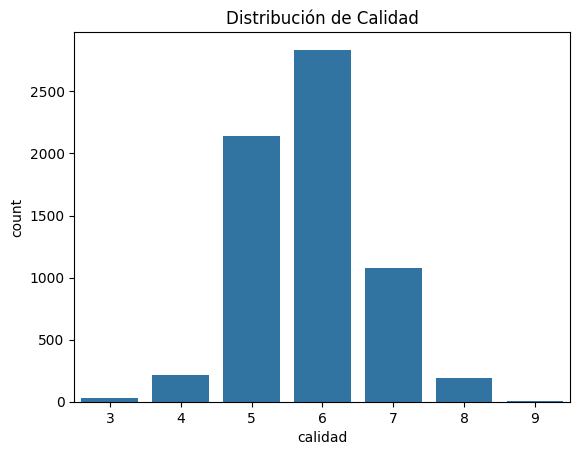

In [10]:
# Exploración de la Variable Objetivo
sns.countplot(x='calidad', data=df)
plt.title('Distribución de Calidad')
plt.show()

In [11]:
# Convertir el Problema a Clasificación Binaria
# Crear nueva columna objetivo
# 1 = vino bueno
# 0 = vino malo
df['vino_bueno'] = (df['calidad'] >= 6).astype(int)

# Eliminar columnas que no ayudan
df = df.drop(['botella_id', 'calidad'], axis=1)

# Convertir color a valores numéricos
df = pd.get_dummies(df, columns=['color'], drop_first=True)

# Separar Variables X e y
# X: contiene las características.
# Y: contiene la variable objetivo.
X = df.drop('vino_bueno', axis=1)
y = df['vino_bueno']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Escalado de Datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Creacion del Modelo XGBoost
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

In [13]:
# Entrenamiendo del modelo mediante 'model.fit'

model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)

Accuracy: 0.7746153846153846


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.65      0.68       481
           1       0.80      0.85      0.83       819

    accuracy                           0.77      1300
   macro avg       0.76      0.75      0.75      1300
weighted avg       0.77      0.77      0.77      1300



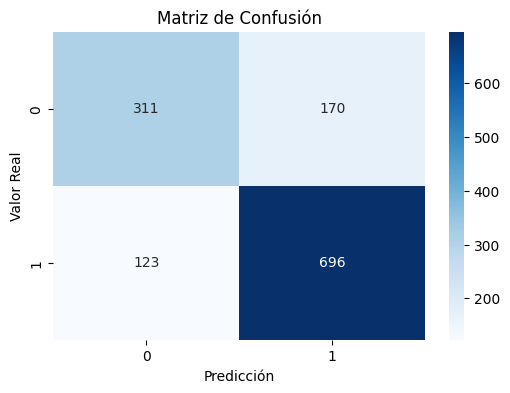

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

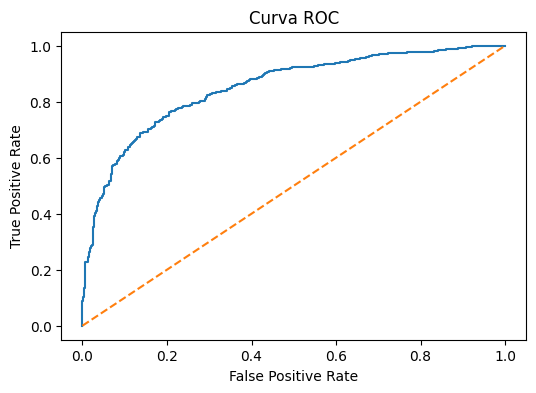

In [18]:
y_probs = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

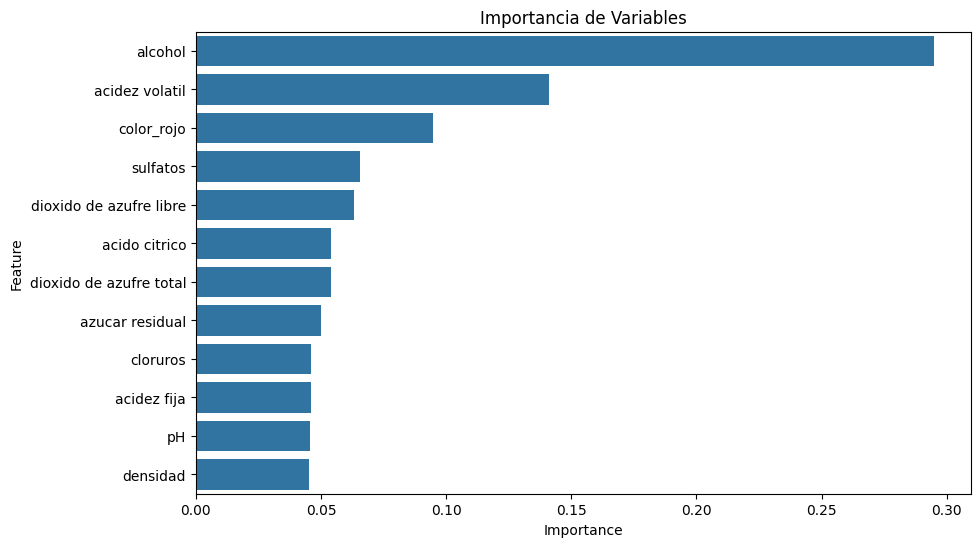

In [19]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importancia de Variables')
plt.show()

In [22]:
import os

# Crear carpeta models
os.makedirs('/workspaces/calidad-vino-xgboost/models', exist_ok=True)

In [23]:
import joblib

# Guardar modelo
joblib.dump(model, '/workspaces/calidad-vino-xgboost/models/modelo.pkl')

# Guardar scaler
joblib.dump(scaler, '/workspaces/calidad-vino-xgboost/models/scaler.pkl')

print("Modelo guardado correctamente")

Modelo guardado correctamente
